#Computer Vision Based Disease Classfication
---

##Section 0: Environment Setup and Library Imports

In [3]:
# Install required libraries
!pip install -q kagglehub
!pip install -q scikit-learn
!pip install -q seaborn

# Core Deep Learning
!pip install -q tensorflow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Image Processing & Utilities
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 761.7 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 139.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 110.9 MB/s eta 0:00:0000:0100:01


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## Section 1: Downloading the Dataset from Kaggle

In [4]:
import kagglehub

# Download dataset from Kaggle
dataset_path = kagglehub.dataset_download(
    "tawsifurrahman/covid19-radiography-database"
)
print("Raw Dataset Path:", dataset_path)

# Check folder structure
print("Initial Contents:", os.listdir(dataset_path))

# Fix folder level if nested
if "COVID-19_Radiography_Dataset" in os.listdir(dataset_path):
    dataset_path = os.path.join(dataset_path, "COVID-19_Radiography_Dataset")

print("Final Dataset Path:", dataset_path)
print("Final Contents:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Raw Dataset Path: /kaggle/input/covid19-radiography-database
Initial Contents: ['COVID-19_Radiography_Dataset']
Final Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset
Final Contents: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']


## Section 2: Hardware Configuration and GPU Detection



In [5]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

if gpus:
    print("GPU is available and will be used automatically by TensorFlow.")
else:
    print("No GPU detected. Running on CPU.")

TensorFlow Version: 2.21.0
Available GPUs: []
No GPU detected. Running on CPU.


## Section 3: Dataset Structure Verification

In [6]:
print("Verifying dataset path...\n")
print("Dataset Path:", dataset_path)

# List all items
items = os.listdir(dataset_path)
print("\nAll items inside dataset folder:")
for item in items:
    print(" -", item)

# Detect only directories (class folders)
class_folders = [
    folder for folder in items
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("\nDetected class folders:")
for folder in class_folders:
    print(" -", folder)

print("\nNumber of class folders detected:", len(class_folders))


Verifying dataset path...

Dataset Path: /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset

All items inside dataset folder:
 - Lung_Opacity.metadata.xlsx
 - Normal.metadata.xlsx
 - README.md.txt
 - COVID.metadata.xlsx
 - Normal
 - Lung_Opacity
 - Viral Pneumonia.metadata.xlsx
 - Viral Pneumonia
 - COVID

Detected class folders:
 - Normal
 - Lung_Opacity
 - Viral Pneumonia
 - COVID

Number of class folders detected: 4


## Section 4: Dataset Cleaning — Removing Segmentation Masks

In [7]:
import shutil
import os

clean_dataset = "/content/xray_dataset"

classes = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]

os.makedirs(clean_dataset, exist_ok=True)

# Corrected: Added "images" to source path
for cls in classes:
    src = os.path.join(dataset_path, cls, "images") # FIXED: Added 'images' subfolder
    dst = os.path.join(clean_dataset, cls)

    os.makedirs(dst, exist_ok=True)

    # Copy all PNG files from source to destination
    for file in os.listdir(src):
        if file.endswith('.png'):  # Only copy PNG files
            shutil.copy(os.path.join(src, file), dst)

    print(f"Copied {len(os.listdir(dst))} images to {cls}")

Copied 3616 images to COVID
Copied 10192 images to Normal
Copied 6012 images to Lung_Opacity
Copied 1345 images to Viral Pneumonia


## Section 5: Dataset Loading and Preprocessing

In [8]:
# Dataset Loading with proper parameters
img_size = (224, 224)
batch_size = 32
seed = 42

# First, create the dataset without validation split to get class names
full_ds = tf.keras.utils.image_dataset_from_directory(
    clean_dataset,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale',
    shuffle=True,
    seed=seed
)

# Store class names for later use
class_names = full_ds.class_names
print("Class names:", class_names)

# Now create train/validation splits
train_ds = tf.keras.utils.image_dataset_from_directory(
    clean_dataset,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    clean_dataset,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='grayscale',
    shuffle=True
)

# Normalize pixel values to [0,1]
normalizer = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizer(x), y),
                        num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalizer(x), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

# Cache and prefetch for performance
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

Found 21165 files belonging to 4 classes.
Class names: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Found 21165 files belonging to 4 classes.
Using 4233 files for validation.


### Section 5.1 Data Verification

In [ ]:
print("\n" + "="*50)
print("DATASET VERIFICATION")
print("="*50)

print("\n1. Class distribution in dataset:")
for i, class_name in enumerate(class_names):
    class_path = os.path.join(clean_dataset, class_name)
    num_images = len(os.listdir(class_path))
    print(f"   {class_name} (index {i}): {num_images} images")

print("\n2. Sample batch from training dataset:")
for images, labels in train_ds.take(1):
    print(f"   Batch shape: {images.shape}")
    print(f"   Labels in batch: {labels.numpy()}")
    unique_labels = np.unique(labels.numpy())
    print(f"   Unique labels in batch: {unique_labels}")

    label_names = [class_names[label] for label in labels.numpy()]
    print(f"   Class names in batch: {label_names[:10]}...")

print(f"\n3. Dataset sizes:")
total_train = sum(1 for _ in train_ds.unbatch())
total_val = sum(1 for _ in val_ds.unbatch())
print(f"   Training samples: {total_train}")
print(f"   Validation samples: {total_val}")
print(f"   Expected split (80-20): {21165*0.8:.0f} - {21165*0.2:.0f}")


DATASET VERIFICATION

1. Class distribution in dataset:
   COVID (index 0): 3616 images
   Lung_Opacity (index 1): 6012 images
   Normal (index 2): 10192 images
   Viral Pneumonia (index 3): 1345 images

2. Sample batch from training dataset:
   Batch shape: (32, 224, 224, 1)
   Labels in batch: [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
   Unique labels in batch: [0 1 2]
   Class names in batch: ['Lung_Opacity', 'Lung_Opacity', 'Normal', 'Normal', 'Normal', 'Normal', 'Lung_Opacity', 'Normal', 'Normal', 'Normal']...

3. Dataset sizes:


### Class Imbalance

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

print("\n" + "="*50)
print("CLASS IMBALANCE HANDLING")
print("="*50)

# Collect all labels from training data
print("Collecting labels for class weight calculation...")
all_labels = []
for images, labels in train_ds:
    all_labels.extend(labels.numpy())
all_labels = np.array(all_labels)

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("\nClass weights (higher weight for minority classes):")
for i, weight in class_weight_dict.items():
    print(f"   {class_names[i]}: {weight:.2f}")


CLASS IMBALANCE HANDLING

Class weights (higher weight for minority classes):
   COVID: 1.46
   Lung_Opacity: 0.87
   Normal: 0.52
   Viral Pneumonia: 4.04


## Section 6: Dataset Visualization and Label Verification



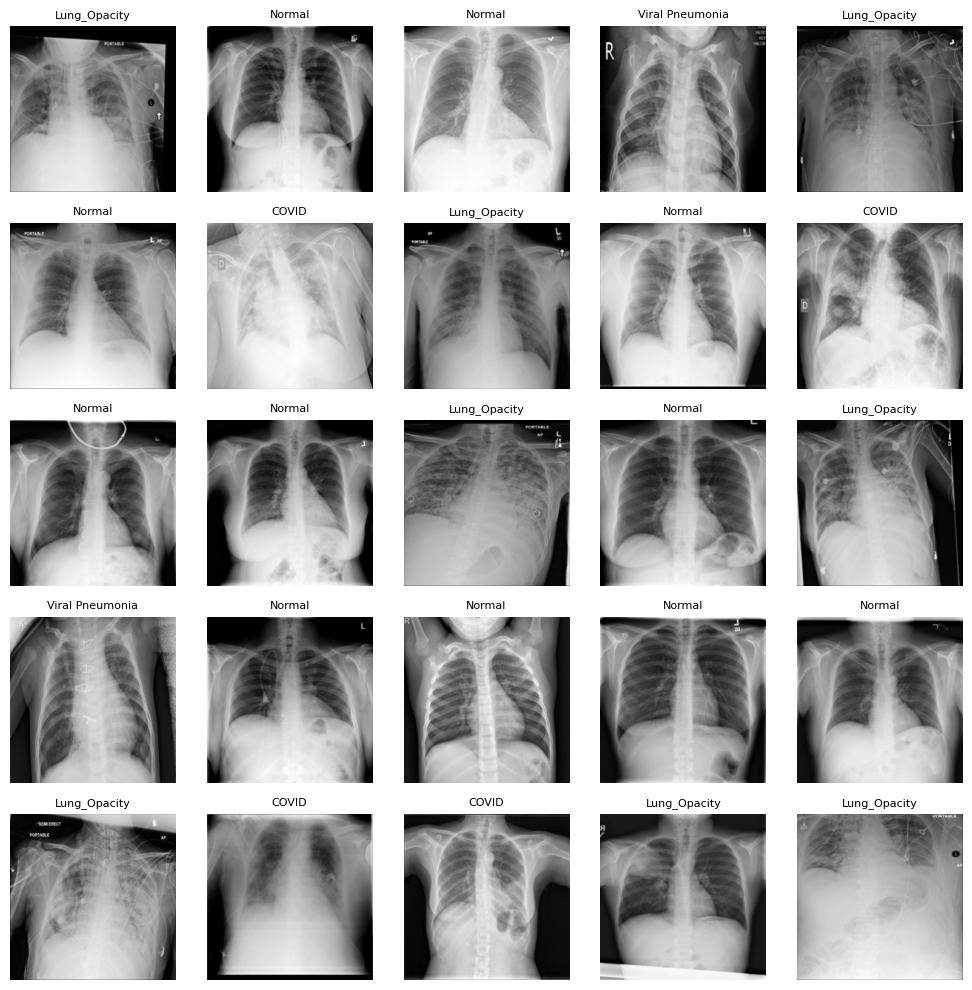

In [ ]:
# Get one batch safely
batch_images, batch_labels = next(iter(train_ds))

# If class_names was lost after .map(), define manually
try:
    class_names
except NameError:
    class_names = train_ds.class_names if hasattr(train_ds, "class_names") else None

# Plot first 25 images
plt.figure(figsize=(10, 10))

for i in range(min(25, batch_images.shape[0])):
    ax = plt.subplot(5, 5, i + 1)

    img = batch_images[i].numpy()

    # Handle grayscale properly
    if img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap="gray")
    else:
        plt.imshow(img)

    if class_names is not None:
        label_idx = int(batch_labels[i].numpy())
        plt.title(class_names[label_idx], fontsize=8)

    plt.axis("off")

plt.tight_layout()
plt.show()

## Section 7: Building the Convolutional Feature Extractor (CNN Base)


In [ ]:
print("\n" + "="*50)
print("MODEL ARCHITECTURE WITH REGULARIZATION")
print("="*50)

conv_base = keras.Sequential([
    layers.Input(shape=(224, 224, 1)),

    layers.Conv2D(32, (3, 3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3, 3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(256, (3, 3), activation="relu", padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

conv_base.summary()


MODEL ARCHITECTURE WITH REGULARIZATION


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,214,788 (100.00 MB)

 Trainable params: 26,212,804 (99.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

## Section 7.1 Data Aug

In [ ]:
print("\n" + "="*50)
print("DATA AUGMENTATION LAYER")
print("="*50)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

print("Data augmentation added: horizontal flip, rotation, zoom, contrast")


DATA AUGMENTATION LAYER
Data augmentation added: horizontal flip, rotation, zoom, contrast


## Section 9: Adding the Classification Head

In [ ]:
conv_base.add(layers.Flatten())
conv_base.add(layers.Dense(128, activation='relu'))
conv_base.add(layers.Dropout(0.5))   # important for medical dataset
conv_base.add(layers.Dense(4, activation='softmax'))

## Section 8: Model Architecture Summary

In [ ]:
conv_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,215,944 (100.01 MB)

 Trainable params: 26,213,960 (100.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

## Section 10: Model Compilation and Training

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

print("\n" + "="*50)
print("MODEL COMPILATION AND TRAINING")
print("="*50)

# Learning rate schedule
initial_learning_rate = 0.001
lr_schedule = optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=1000,
    decay_rate=0.9,
    staircase=True
)

# Compile model
conv_base.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Removed ReduceLROnPlateau as it conflicts with LearningRateSchedule
# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.5,
#     patience=3,
#     min_lr=1e-6,
#     verbose=1
# )

# Apply augmentation to training dataset
def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

train_ds_augmented = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

# Train model
history = conv_base.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=30,  # Increased epochs
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

KeyboardInterrupt: 

## Section 11: Final Training and Validation Accuracy

In [ ]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Final Training Accuracy:", train_acc)
print("Final Validation Accuracy:", val_acc)

## Section 12: Training vs Validation Accuracy Visualization

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(len(acc))

plt.figure(figsize=(6,5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## Section 13: Training and Validation Performance Curves

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

## Section 14: Generating Predictions on the Validation Dataset

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = conv_base.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    y_pred.extend(predicted_classes)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

## Section 15: Prediction Consistency Check

In [ ]:
print("Total True Labels:", len(y_true))
print("Total Predictions:", len(y_pred))

print("\nFirst 10 True Labels:")
print(y_true[:10])

print("\nFirst 10 Predictions:")
print(y_pred[:10])

## Section 15.1 Performance Analysis

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("DETAILED PERFORMANCE ANALYSIS")
print("="*50)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class accuracy
print("\nPer-class Accuracy:")
for i, class_name in enumerate(class_names):
    mask = y_true == i
    if np.sum(mask) > 0:
        acc = np.mean(y_pred[mask] == y_true[mask])
        print(f"   {class_name}: {acc:.2%} ({np.sum(mask)} samples)")

## Section 16: Validation Accuracy Calculation

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred)

print("Validation Accuracy:", accuracy)

## Section 17: Precision Calculation

In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(y_true, y_pred, average='weighted')
print("Precision:", precision)

## Section 18: Recall Calculation

In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(y_true, y_pred, average='weighted')
print("Recall:", recall)

## Section 19: F1 Score Calculation

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("F1 Score:", f1)

## Section 20: Visualizing Sample Predictions

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the already existing class_folders variable
class_names = class_folders

plt.figure(figsize=(10,10))

for images, labels in val_ds.take(1):

    preds = conv_base.predict(images)
    preds = np.argmax(preds, axis=1)

    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        img = images[i].numpy().squeeze()
        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]

        plt.imshow(img, cmap="gray")
        plt.title(f"T:{true_label}\nP:{pred_label}")
        plt.axis("off")

plt.show()

## Section 22: Save the Model

In [ ]:
conv_base.save("xray_disease_model.keras")